# Correlated Features and Autoencoder Representations

When features in the data have statistical dependencies, does the
autoencoder learn representations that reflect those relationships?

This notebook trains a TiedLinearRelu autoencoder under four
correlation regimes and compares what each one learns:

1. **SparseUniform** -- independent baseline (no correlation)
2. **HierarchicalPairs** -- parent-child dependency
3. **CorrelatedPairs** -- pairwise positive correlation
4. **AnticorrelatedPairs** -- mutual exclusion

Throughout, we hold the bottleneck fixed (50 features, 15 hidden dims)
and examine how correlation structure affects loss, superposition,
feature norms, and the geometry of the learned W matrix.

**Key insight:** correlated features can share hidden dimensions more
efficiently because the autoencoder only needs to distinguish features
that actually co-occur. Anticorrelated (mutually exclusive) features
can be packed into the same direction as antipodal pairs.

In [1]:
import torch
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from occhio import ToyModel
from occhio.autoencoders import TiedLinearRelu
from occhio.distributions import (
    SparseUniform,
    HierarchicalPairs,
    CorrelatedPairs,
    AnticorrelatedPairs,
)

pio.renderers.default = "png"
torch.manual_seed(42)

In [2]:
# -- Shared experiment parameters --

N_FEATURES = 50
N_HIDDEN = 15
P_ACTIVE = 0.01
N_EPOCHS = 25000
BATCH_SIZE = 1024
LR = 3e-4
DEVICE = "cpu"

# Importance decay: earlier features matter more
importances = 0.99 ** torch.arange(N_FEATURES)

print(f"Bottleneck: {N_FEATURES} features -> {N_HIDDEN} hidden dims")
print(f"Compression ratio: {N_FEATURES / N_HIDDEN:.1f}x")
print(f"Expected active features per sample: {N_FEATURES * P_ACTIVE:.1f}")

Bottleneck: 50 features -> 15 hidden dims
Compression ratio: 3.3x
Expected active features per sample: 0.5


In [3]:
def train(dist, seed=42):
    """Train a TiedLinearRelu on the given distribution."""
    gen = torch.Generator(DEVICE).manual_seed(seed)
    ae = TiedLinearRelu(N_FEATURES, N_HIDDEN, device=DEVICE, generator=gen)
    model = ToyModel(dist, ae, importances=importances)
    losses, _ = model.fit(
        n_epochs=N_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
    )
    return model, losses

---
## Part 1: SparseUniform -- Independent Baseline

Each feature fires independently with probability `p_active=0.01`.
No correlation between any pair of features. This is the standard
setup from the Toy Models of Superposition paper.

In [4]:
dist_uniform = SparseUniform(n_features=N_FEATURES, p_active=P_ACTIVE, device=DEVICE)

# Verify: no correlation between features
samples = dist_uniform.sample(50_000)
active = (samples > 0).float()
emp_corr = torch.corrcoef(active.T)
off_diag = emp_corr[~torch.eye(N_FEATURES, dtype=bool)]
print(f"SparseUniform empirical off-diagonal correlation:")
print(f"  mean = {off_diag.mean():.4f}, std = {off_diag.std():.4f}")
print(f"  (should be near zero -- features are independent)")

model_uniform, losses_uniform = train(dist_uniform)
print(f"\nFinal loss: {losses_uniform[-1]:.6f}")
print(f"Superposition: {model_uniform.superposition.item():.4f}")

SparseUniform empirical off-diagonal correlation:
  mean = -0.0002, std = 0.0045
  (should be near zero -- features are independent)



Final loss: 0.006862
Superposition: 0.5469


---
## Part 2: HierarchicalPairs -- Parent-Child Correlation

Features are organized in 25 pairs. The parent (even index) fires
with probability `p_active`. The child (odd index) fires only when
the parent is active, with probability `p_follow=0.7`.

This creates asymmetric correlation: seeing the child guarantees
the parent is active, but not vice versa.

In [5]:
dist_hier = HierarchicalPairs(
    n_features=N_FEATURES,
    p_active=P_ACTIVE,
    p_follow=0.7,
    device=DEVICE,
)

# Verify parent-child correlation
samples_h = dist_hier.sample(50_000)
active_h = (samples_h > 0).float()
pair_corrs = [
    torch.corrcoef(active_h[:, [2 * i, 2 * i + 1]].T)[0, 1].item()
    for i in range(N_FEATURES // 2)
]
print(f"HierarchicalPairs parent-child correlations:")
print(f"  mean = {np.mean(pair_corrs):.4f}")
print(f"  range = [{min(pair_corrs):.4f}, {max(pair_corrs):.4f}]")

model_hier, losses_hier = train(dist_hier)
print(f"\nFinal loss: {losses_hier[-1]:.6f}")
print(f"Superposition: {model_hier.superposition.item():.4f}")

HierarchicalPairs parent-child correlations:
  mean = 0.8412
  range = [0.8174, 0.8570]



Final loss: 0.003401
Superposition: 0.6362


---
## Part 3: CorrelatedPairs -- Pairwise Positive Correlation

Features are organized in 25 pairs. A shared gate activates each
pair, then each member fires independently. This creates symmetric
positive correlation: features in a pair tend to co-occur.

We parameterize via `density` (effective firing rate per feature)
and `correlation` (target within-pair correlation), which lets us
match the baseline's effective density while controlling correlation
strength.

In [6]:
dist_corr = CorrelatedPairs(
    n_features=N_FEATURES,
    density=P_ACTIVE,
    correlation=0.8,
    device=DEVICE,
)

# Show the derived parameters
print(f"CorrelatedPairs derived parameters:")
print(f"  p_active (pair gate) = {dist_corr.p_active[0].item():.4f}")
print(f"  p_individual = {dist_corr.p_individual[0].item():.4f}")
print(
    f"  density = p_active * p_individual = {dist_corr.p_active[0].item() * dist_corr.p_individual[0].item():.4f}"
)

# Verify correlation empirically
samples_c = dist_corr.sample(50_000)
active_c = (samples_c > 0).float()
pair_corrs_c = [
    torch.corrcoef(active_c[:, [2 * i, 2 * i + 1]].T)[0, 1].item()
    for i in range(N_FEATURES // 2)
]
print(f"\nEmpirical within-pair correlation:")
print(f"  mean = {np.nanmean(pair_corrs_c):.4f} (target = 0.8)")

model_corr, losses_corr = train(dist_corr)
print(f"\nFinal loss: {losses_corr[-1]:.6f}")
print(f"Superposition: {model_corr.superposition.item():.4f}")

CorrelatedPairs derived parameters:
  p_active (pair gate) = 0.0125
  p_individual = 0.8020
  density = p_active * p_individual = 0.0100

Empirical within-pair correlation:
  mean = 0.7974 (target = 0.8)



Final loss: 0.005979
Superposition: 0.6164


---
## Part 4: AnticorrelatedPairs -- Mutual Exclusion

Features are organized in 25 pairs. When a pair activates, exactly
one of the two fires (chosen uniformly). The two features in a pair
never co-occur -- maximal negative correlation.

This is the ideal scenario for antipodal packing: two mutually
exclusive features can share a single hidden dimension by pointing
in opposite directions, with the ReLU decoder selecting the right one.

In [7]:
dist_anti = AnticorrelatedPairs(
    n_features=N_FEATURES,
    p_active=2 * P_ACTIVE,  # Each feature fires at rate p_active/2
    device=DEVICE,
)

# Verify mutual exclusion
samples_a = dist_anti.sample(50_000)
active_a = (samples_a > 0).float()
both_active = sum(
    (active_a[:, 2 * i] * active_a[:, 2 * i + 1]).sum().item()
    for i in range(N_FEATURES // 2)
)
print(f"AnticorrelatedPairs:")
print(f"  Both-active count across all pairs: {int(both_active)} (should be 0)")
print(f"  Per-feature density: {active_a.mean():.4f}")

model_anti, losses_anti = train(dist_anti)
print(f"\nFinal loss: {losses_anti[-1]:.6f}")
print(f"Superposition: {model_anti.superposition.item():.4f}")

AnticorrelatedPairs:
  Both-active count across all pairs: 0 (should be 0)
  Per-feature density: 0.0100



Final loss: 0.008239
Superposition: 0.5530


---
## Comparison: Loss Curves

How does the correlation structure affect training dynamics and
final reconstruction quality?

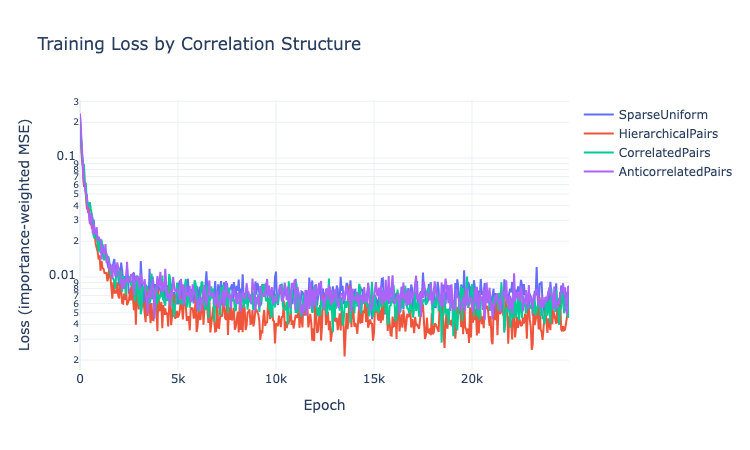

In [8]:
configs = {
    "SparseUniform": losses_uniform,
    "HierarchicalPairs": losses_hier,
    "CorrelatedPairs": losses_corr,
    "AnticorrelatedPairs": losses_anti,
}

colors = {
    "SparseUniform": "#636EFA",
    "HierarchicalPairs": "#EF553B",
    "CorrelatedPairs": "#00CC96",
    "AnticorrelatedPairs": "#AB63FA",
}

fig_loss = go.Figure()
for name, losses in configs.items():
    step = max(1, len(losses) // 500)
    epochs = list(range(0, len(losses), step))
    sampled = [losses[i] for i in epochs]
    fig_loss.add_trace(
        go.Scatter(
            x=epochs,
            y=sampled,
            mode="lines",
            name=name,
            line=dict(color=colors[name], width=2),
        )
    )

fig_loss.update_layout(
    title="Training Loss by Correlation Structure",
    xaxis_title="Epoch",
    yaxis_title="Loss (importance-weighted MSE)",
    yaxis_type="log",
    template="plotly_white",
    height=450,
    width=750,
)
fig_loss.show()

---
## Comparison: Superposition and Feature Norms

The superposition metric (mean max absolute cosine similarity) and
the distribution of feature norms reveal how the model allocates
capacity under each correlation regime.

In [9]:
models = {
    "SparseUniform": model_uniform,
    "HierarchicalPairs": model_hier,
    "CorrelatedPairs": model_corr,
    "AnticorrelatedPairs": model_anti,
}

# Summary table
print(
    f"{'Distribution':<22} {'Loss':>8} {'Superpos.':>10} "
    f"{'Mean Norm':>10} {'Mean Dim':>10}"
)
print("-" * 64)
for name, m in models.items():
    final_loss = configs[name][-1]
    sup = m.superposition.item()
    mn = m.feature_norms.mean().item()
    md = m.feature_dimensionalities.mean().item()
    print(f"{name:<22} {final_loss:>8.5f} {sup:>10.4f} {mn:>10.4f} {md:>10.4f}")

Distribution               Loss  Superpos.  Mean Norm   Mean Dim
----------------------------------------------------------------
SparseUniform           0.00686     0.5469     1.1113     0.2983
HierarchicalPairs       0.00340     0.6362     1.0640     0.2933
CorrelatedPairs         0.00598     0.6164     1.0671     0.2945
AnticorrelatedPairs     0.00824     0.5530     1.1120     0.2982


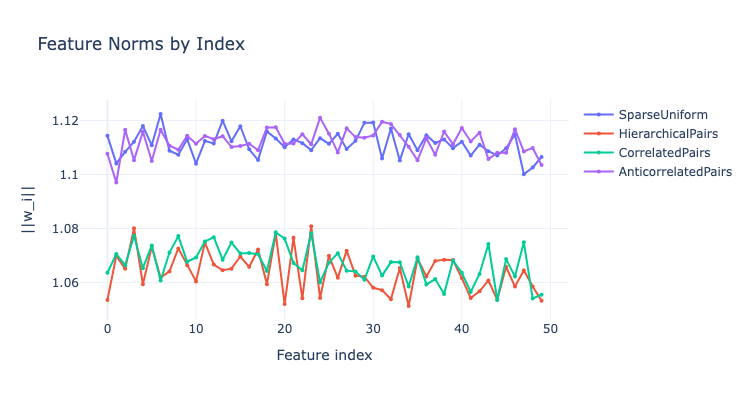

In [10]:
# Feature norms by index -- shows how importance decay interacts
# with correlation structure

fig_norms = go.Figure()
for name, m in models.items():
    norms = m.feature_norms.cpu().numpy()
    fig_norms.add_trace(
        go.Scatter(
            x=list(range(N_FEATURES)),
            y=norms,
            mode="lines+markers",
            name=name,
            line=dict(color=colors[name], width=2),
            marker=dict(size=4),
        )
    )

fig_norms.update_layout(
    title="Feature Norms by Index",
    xaxis_title="Feature index",
    yaxis_title="||w_i||",
    template="plotly_white",
    height=400,
    width=750,
)
fig_norms.show()

---
## Comparison: Cosine Similarity Structure

The cosine similarity matrix between feature embeddings shows which
features the model has placed in similar or opposing directions.

- **SparseUniform**: no prior structure, optimizer finds arbitrary
  packing.
- **HierarchicalPairs**: parent-child pairs may cluster together.
- **CorrelatedPairs**: co-occurring features may share directions.
- **AnticorrelatedPairs**: mutually exclusive features should form
  antipodal pairs (cosine similarity near -1).

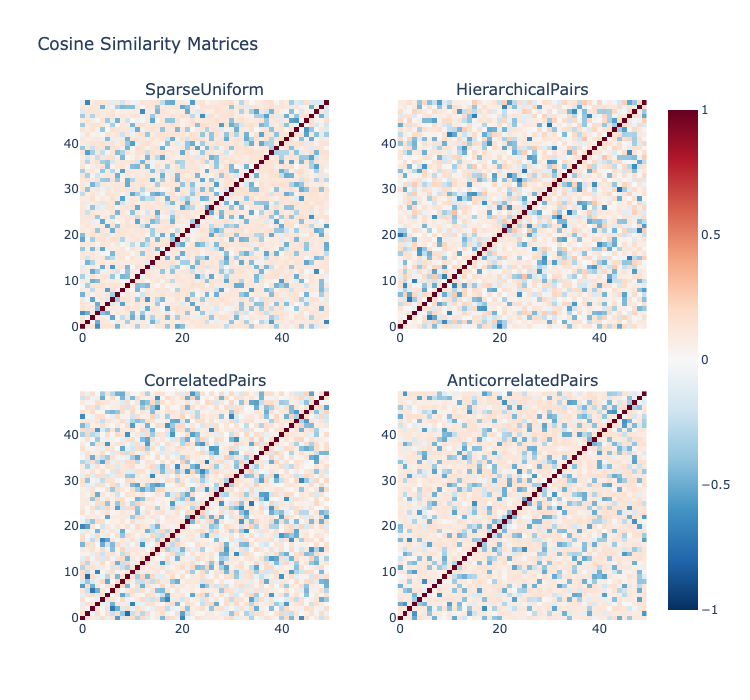

In [11]:
fig_cos = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=list(models.keys()),
    horizontal_spacing=0.12,
    vertical_spacing=0.12,
)

positions = [(1, 1), (1, 2), (2, 1), (2, 2)]
for (row, col), (name, m) in zip(positions, models.items()):
    cos_sim = m.cosine_similarity_matrix.cpu().numpy()
    fig_cos.add_trace(
        go.Heatmap(
            z=cos_sim,
            colorscale="RdBu_r",
            zmid=0,
            zmin=-1,
            zmax=1,
            showscale=(row == 2 and col == 2),
        ),
        row=row,
        col=col,
    )

fig_cos.update_layout(
    title="Cosine Similarity Matrices",
    template="plotly_white",
    height=700,
    width=750,
)
fig_cos.show()

---
## Within-Pair Cosine Similarity

For the three paired distributions, we can directly measure whether
features in the same pair have aligned, orthogonal, or opposing
embeddings. This is where correlation structure should leave the
clearest geometric fingerprint.

Distribution            Mean Pair Cos      Std
------------------------------------------------
HierarchicalPairs             +0.1602   0.0144
CorrelatedPairs               +0.1607   0.0146
AnticorrelatedPairs           -0.0337   0.2104


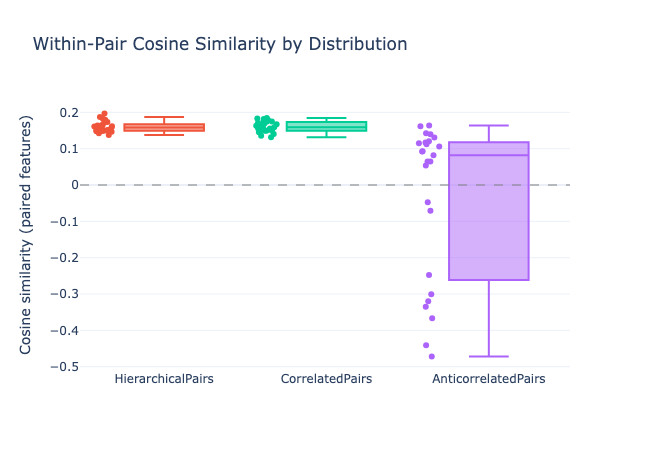

In [12]:
n_pairs = N_FEATURES // 2
pair_models = {
    "HierarchicalPairs": model_hier,
    "CorrelatedPairs": model_corr,
    "AnticorrelatedPairs": model_anti,
}

print(f"{'Distribution':<22} {'Mean Pair Cos':>14} {'Std':>8}")
print("-" * 48)

fig_pairs = go.Figure()
for name, m in pair_models.items():
    cos_mat = m.cosine_similarity_matrix
    pair_cos = [cos_mat[2 * i, 2 * i + 1].item() for i in range(n_pairs)]
    mean_pc = np.mean(pair_cos)
    std_pc = np.std(pair_cos)
    print(f"{name:<22} {mean_pc:>+14.4f} {std_pc:>8.4f}")

    fig_pairs.add_trace(
        go.Box(
            y=pair_cos,
            name=name,
            marker_color=colors[name],
            boxpoints="all",
            jitter=0.3,
            pointpos=-1.5,
        )
    )

fig_pairs.add_hline(y=0, line_dash="dash", line_color="gray", line_width=1)
fig_pairs.update_layout(
    title="Within-Pair Cosine Similarity by Distribution",
    yaxis_title="Cosine similarity (paired features)",
    template="plotly_white",
    height=450,
    width=650,
    showlegend=False,
)
fig_pairs.show()

---
## Interference Budget: How Correlation Affects Packing Efficiency

Total interference per feature measures how much a feature's
reconstruction is contaminated by other features. Lower total
interference means the model has found a cleaner representation.

Anticorrelated features can pack more efficiently (antipodal pairs
share a dimension perfectly), while positively correlated features
face a dilemma: co-occurring features that share a direction will
interfere whenever both are active.

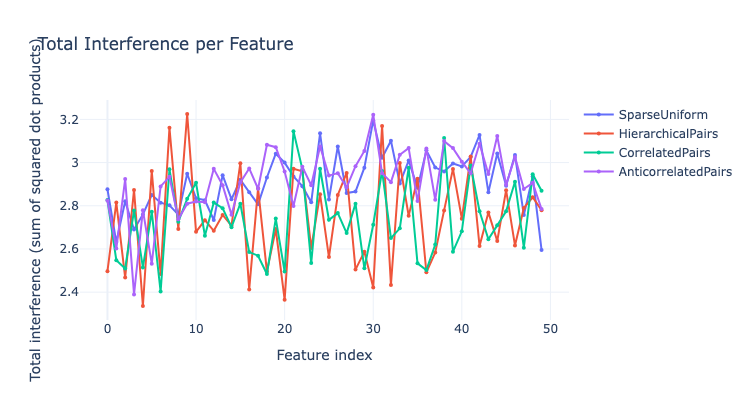

In [13]:
fig_interf = go.Figure()
for name, m in models.items():
    total_interf = m.total_feature_interferences.cpu().numpy()
    fig_interf.add_trace(
        go.Scatter(
            x=list(range(N_FEATURES)),
            y=total_interf,
            mode="lines+markers",
            name=name,
            line=dict(color=colors[name], width=2),
            marker=dict(size=4),
        )
    )

fig_interf.update_layout(
    title="Total Interference per Feature",
    xaxis_title="Feature index",
    yaxis_title="Total interference (sum of squared dot products)",
    template="plotly_white",
    height=400,
    width=750,
)
fig_interf.show()

---
## Feature Dimensionality

Feature dimensionality measures how many effective hidden dimensions
each feature occupies, accounting for interference. A feature with
dimensionality 1.0 has a clean, dedicated direction; values below
1.0 indicate superposition.

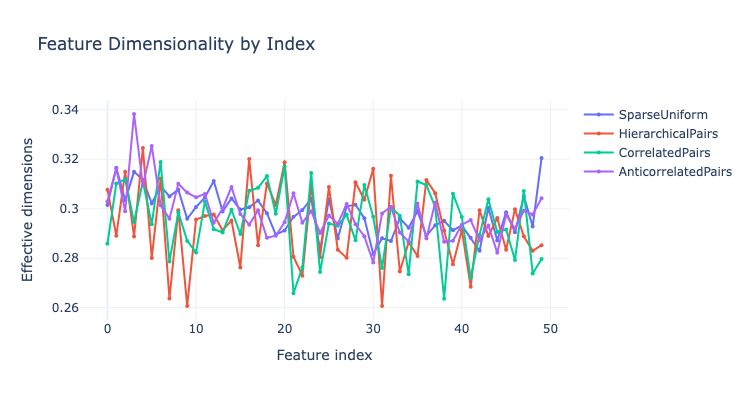

In [14]:
fig_dim = go.Figure()
for name, m in models.items():
    dims = m.feature_dimensionalities.cpu().numpy()
    fig_dim.add_trace(
        go.Scatter(
            x=list(range(N_FEATURES)),
            y=dims,
            mode="lines+markers",
            name=name,
            line=dict(color=colors[name], width=2),
            marker=dict(size=4),
        )
    )

fig_dim.update_layout(
    title="Feature Dimensionality by Index",
    xaxis_title="Feature index",
    yaxis_title="Effective dimensions",
    template="plotly_white",
    height=400,
    width=750,
)
fig_dim.show()

---
## Data Correlation vs Learned Cosine Similarity

The scatter plot below asks: does the autoencoder's weight geometry
mirror the statistical structure of the data? For each pair of
features, we plot the empirical activation correlation (x-axis)
against the cosine similarity of the learned embeddings (y-axis).

A positive trend would indicate the model places co-occurring
features in similar directions and separates anticorrelated ones.

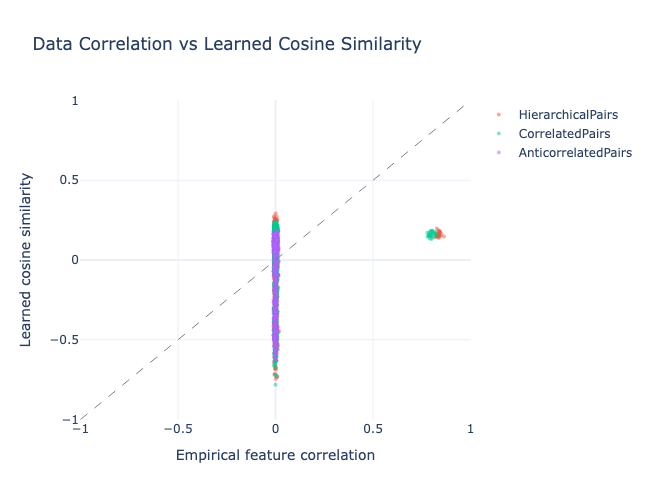

In [15]:
fig_scatter = go.Figure()

scatter_configs = {
    "HierarchicalPairs": (dist_hier, model_hier),
    "CorrelatedPairs": (dist_corr, model_corr),
    "AnticorrelatedPairs": (dist_anti, model_anti),
}

for name, (dist, m) in scatter_configs.items():
    samps = dist.sample(50_000)
    active = (samps > 0).float()
    emp_corr = torch.corrcoef(active.T)
    cos_mat = m.cosine_similarity_matrix

    emp_vals, cos_vals = [], []
    for i in range(N_FEATURES):
        for j in range(i + 1, N_FEATURES):
            r = emp_corr[i, j].item()
            c = cos_mat[i, j].item()
            if not np.isnan(r):
                emp_vals.append(r)
                cos_vals.append(c)

    fig_scatter.add_trace(
        go.Scatter(
            x=emp_vals,
            y=cos_vals,
            mode="markers",
            marker=dict(size=4, opacity=0.5, color=colors[name]),
            name=name,
        )
    )

fig_scatter.add_shape(
    type="line",
    x0=-1,
    x1=1,
    y0=-1,
    y1=1,
    line=dict(dash="dash", color="gray", width=1),
)
fig_scatter.update_layout(
    title="Data Correlation vs Learned Cosine Similarity",
    xaxis_title="Empirical feature correlation",
    yaxis_title="Learned cosine similarity",
    template="plotly_white",
    height=500,
    width=650,
)
fig_scatter.show()

---
## Summary

This experiment demonstrates how feature correlation structure
shapes autoencoder representations in a bottleneck setting:

1. **Independent features** (SparseUniform) serve as the baseline.
   The optimizer packs features into superposition without any
   correlation-driven preference for which features share directions.

2. **Hierarchical pairs** create asymmetric co-occurrence. The model
   may align parent-child pairs, but the effect is modulated by the
   importance decay and sparsity level.

3. **Correlated pairs** create symmetric co-occurrence. Features
   that always fire together can theoretically share a direction,
   but the model must also represent them distinctly when only one
   is active. The tension between sharing and distinguishing shapes
   the learned geometry.

4. **Anticorrelated pairs** are the clearest case: mutually exclusive
   features can be packed as antipodal pairs, each occupying half a
   hidden dimension. This is the most efficient packing strategy
   and should yield the lowest loss relative to effective capacity.

The key insight is that **correlation structure determines the
efficiency of superposition**. Anticorrelated features pack most
efficiently because they never interfere. Correlated features face
a trade-off between sharing directions (efficient) and avoiding
interference (accurate). The autoencoder navigates this trade-off
through the geometry of its weight matrix.